# Example API Surface

Canonical API/runtime routing example notebook for the public `api` facade.

## Scope

This notebook is the canonical example surface for `example_api_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import io
import json
import os
import re
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_api_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_api_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view. Canonical retained execution in this repo state is CPU-oriented, but the notebook calling pattern remains CPU/GPU portable and explicitly parameterized for `float32` and `float64`.

In [2]:
SUPPORTED_JAX_MODES = ('cpu', 'gpu')
SUPPORTED_JAX_DTYPES = ('float32', 'float64')
if JAX_MODE not in SUPPORTED_JAX_MODES:
    raise ValueError(f'Unsupported JAX_MODE: {JAX_MODE}')
if JAX_DTYPE not in SUPPORTED_JAX_DTYPES:
    raise ValueError(f'Unsupported JAX_DTYPE: {JAX_DTYPE}')
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
print('supported_jax_modes:', SUPPORTED_JAX_MODES)
print('supported_jax_dtypes:', SUPPORTED_JAX_DTYPES)
print('validation_slice:', 'cpu_current__gpu_portable_contract')
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
supported_jax_modes: ('cpu', 'gpu')
supported_jax_dtypes: ('float32', 'float64')
validation_slice: cpu_current__gpu_portable_contract
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Object/Input Construction

Build representative scalar, interval, and matrix inputs that exercise the routed API.

In [3]:
import jax.numpy as jnp
from arbplusjax import acb_core, api, double_interval as di

x = jnp.asarray(0.5, dtype=jnp.float64)
y = jnp.asarray(2.0, dtype=jnp.float64)
s = jnp.asarray(2.5, dtype=jnp.float64)
z = jnp.asarray(1.0, dtype=jnp.float64)
a_mid = jnp.array([[4.0, 1.0], [1.0, 3.0]], dtype=jnp.float64)
rhs_mid = jnp.array([[1.0], [2.0]], dtype=jnp.float64)
a = di.interval(a_mid, a_mid)
rhs = di.interval(rhs_mid, rhs_mid)
c_mid = jnp.array([[4.0 + 0.0j, 1.0 + 1.0j], [1.0 - 1.0j, 5.0 + 0.0j]], dtype=jnp.complex128)
c_rhs_mid = jnp.array([[1.0 + 0.5j], [2.0 - 0.25j]], dtype=jnp.complex128)
c_a = acb_core.acb_box(di.interval(jnp.real(c_mid), jnp.real(c_mid)), di.interval(jnp.imag(c_mid), jnp.imag(c_mid)))
c_rhs = acb_core.acb_box(di.interval(jnp.real(c_rhs_mid), jnp.real(c_rhs_mid)), di.interval(jnp.imag(c_rhs_mid), jnp.imag(c_rhs_mid)))

## Direct Usage

Compare direct routed `evaluate()` calls against the explicit public entrypoints.

In [4]:
api_results = {
    'besselk_routed': api.evaluate('besselk', x, y, implementation='cuda_besselk', value_kind='real'),
    'incgamma_direct': api.incomplete_gamma_upper(s, z, method='quadrature', samples_per_panel=8, max_panels=16),
    'incgamma_routed': api.evaluate('incomplete_gamma_upper', s, z, method='quadrature', method_params={'samples_per_panel': 8, 'max_panels': 16}),
    'arb_mat_solve_routed': api.evaluate('arb_mat_solve', a, rhs, mode='basic', value_kind='real_matrix', dtype='float64'),
    'acb_mat_solve_routed': api.evaluate('acb_mat_solve', c_a, c_rhs, mode='basic', value_kind='complex_matrix', dtype='float64'),
}
display(api_results)

{'besselk_routed': Array(0.11993777, dtype=float64),
 'incgamma_direct': Array(0.72173362, dtype=float64),
 'incgamma_routed': Array(0.72173362, dtype=float64),
 'arb_mat_solve_routed': Array([[[0.09090909, 0.09090909]],
 
        [[0.63636364, 0.63636364]]], dtype=float64),
 'acb_mat_solve_routed': Array([[[ 0.15277778,  0.15277778,  0.04166667,  0.04166667]],
 
        [[ 0.36111111,  0.36111111, -0.02777778, -0.02777778]]],      dtype=float64)}

## Production Pattern

For routed library use, favor explicit `evaluate()` or pre-bound batch entrypoints with fixed `dtype`, `mode`, and `pad_to` so service calls do not constantly recompile on batch-length drift. Keep matrix plans cached when an operation supports prepare/apply separation.

In [5]:
real_batch = jnp.asarray([0.5, 1.0, 1.5, 2.0, 2.5], dtype=jnp.float64)
gamma_bound = api.bind_point_batch('incomplete_gamma_upper', dtype='float64', pad_to=8, method='quadrature', regularized=True)
solve_bound = api.bind_interval_batch('arb_mat_solve', mode='basic', dtype='float64', pad_to=4, prec_bits=53)
a_batch = di.interval(jnp.stack([a_mid, a_mid], axis=0), jnp.stack([a_mid, a_mid], axis=0))
rhs_batch = di.interval(jnp.stack([rhs_mid, rhs_mid], axis=0), jnp.stack([rhs_mid, rhs_mid], axis=0))
vec_mid = jnp.array([1.0, 2.0], dtype=jnp.float64)
vec = di.interval(vec_mid, vec_mid)
cached_plan = api.eval_point('arb_mat_matvec_cached_prepare', a)
api_service_results = {
    'gamma_bound': gamma_bound(real_batch, jnp.asarray([1.0, 1.1, 1.2, 1.3, 1.4], dtype=jnp.float64)),
    'solve_bound': solve_bound(a_batch, rhs_batch),
    'cached_matvec': api.eval_point('arb_mat_matvec_cached_apply', cached_plan, vec),
}
display(api_service_results)

{'gamma_bound': Array([0.15729921, 0.33287108, 0.49363462, 0.62682311, 0.73078645],      dtype=float64),
 'solve_bound': Array([[[[0.09090909, 0.09090909]],
 
         [[0.63636364, 0.63636364]]],
 
 
        [[[0.09090909, 0.09090909]],
 
         [[0.63636364, 0.63636364]]]], dtype=float64),
 'cached_matvec': Array([6., 7.], dtype=float64)}

## Extending Benchmarks

To extend routed benchmarks, add the target operation or implementation branch in `benchmark_api_surface.py`, `benchmark_special_function_service_api.py`, or `benchmark_matrix_service_api.py`, depending on whether the concern is generic API routing, special-function services, or matrix services.

## Fast JAX Point Pattern

The routed API should still show the compiled point-batch path explicitly. Use `bind_point_batch_jit()` when a routed function is going to be called repeatedly in a point-mode service loop.

In [6]:
import jax
jit_gamma = api.bind_point_batch_jit('incomplete_gamma_upper', dtype='float64', pad_to=8, method='quadrature', regularized=True)
jit_out = jit_gamma(real_batch, jnp.asarray([1.0, 1.1, 1.2, 1.3, 1.4], dtype=jnp.float64))
vmap_out = jax.vmap(lambda s_i, z_i: api.evaluate('incomplete_gamma_upper', s_i, z_i, method='quadrature', regularized=True))(real_batch, jnp.asarray([1.0, 1.1, 1.2, 1.3, 1.4], dtype=jnp.float64))
display({'jit_shape': jit_out.shape, 'jit_matches_vmap': bool(jnp.allclose(jit_out, vmap_out, rtol=1e-6, atol=1e-6))})

{'jit_shape': (5,), 'jit_matches_vmap': True}

## AD Product Pattern

The routed API should demonstrate AD in both directions through the same metadata-aware entrypoints used in product code. This section differentiates routed incomplete-gamma evaluation over both `z` and `s` sweeps and plots the paired sensitivities.

,z,primal_z,grad_z,s,primal_s,grad_s
0,0.250000,0.680941,-0.097350,1.500000,0.408370,0.213505
1,0.304348,0.694086,-0.123845,1.565217,0.422618,0.223527
2,0.358696,0.705437,-0.150075,1.630435,0.437538,0.234086
3,0.413043,0.715010,-0.175635,1.695652,0.453164,0.245211
4,0.467391,0.722844,-0.200233,1.760870,0.469535,0.256935


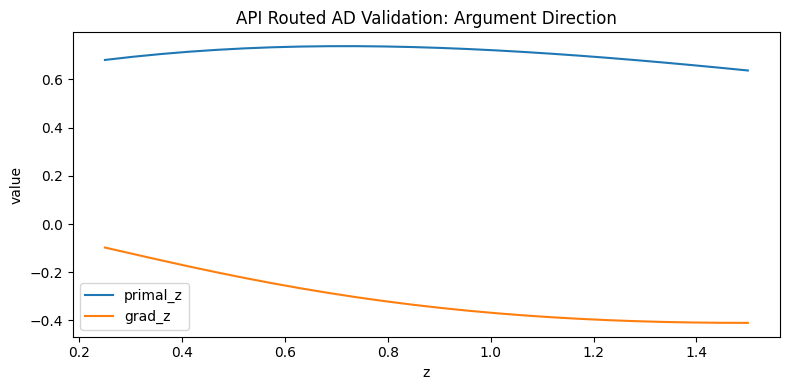

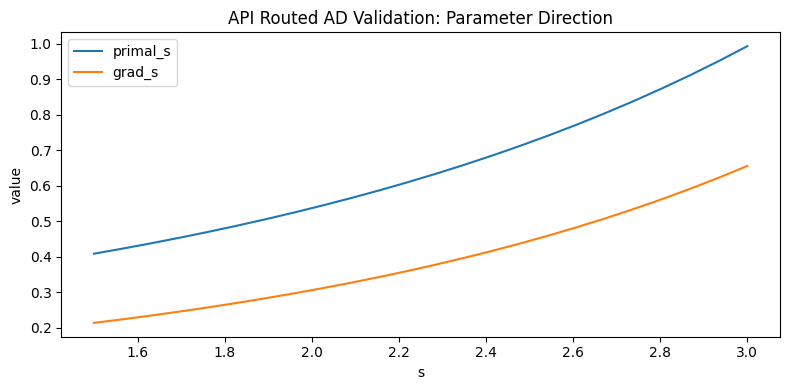

In [7]:
import jax
s_fixed = jnp.asarray(2.5, dtype=jnp.float64)
z_fixed = jnp.asarray(1.0, dtype=jnp.float64)
def routed_loss_z(zv):
    return api.evaluate('incomplete_gamma_upper', s_fixed, zv, method='quadrature', method_params={'samples_per_panel': 8, 'max_panels': 16})
def routed_loss_s(sv):
    return api.evaluate('incomplete_gamma_upper', sv, z_fixed, method='quadrature', method_params={'samples_per_panel': 8, 'max_panels': 16})
z_sweep = jnp.linspace(0.25, 1.5, 24, dtype=jnp.float64)
s_sweep = jnp.linspace(1.5, 3.0, 24, dtype=jnp.float64)
primal_z = jax.vmap(routed_loss_z)(z_sweep)
grad_z = jax.vmap(jax.grad(routed_loss_z))(z_sweep)
primal_s = jax.vmap(routed_loss_s)(s_sweep)
grad_s = jax.vmap(jax.grad(routed_loss_s))(s_sweep)
ad_df = pd.DataFrame({'z': np.asarray(z_sweep), 'primal_z': np.asarray(primal_z), 'grad_z': np.asarray(grad_z), 's': np.asarray(s_sweep), 'primal_s': np.asarray(primal_s), 'grad_s': np.asarray(grad_s)})
display(ad_df.head())
ax = ad_df.plot(x='z', y=['primal_z', 'grad_z'], figsize=(8, 4), title='API Routed AD Validation: Argument Direction')
ax.set_ylabel('value')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_argument_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()
ax = ad_df.plot(x='s', y=['primal_s', 'grad_s'], figsize=(8, 4), title='API Routed AD Validation: Parameter Direction')
ax.set_ylabel('value')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_parameter_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Parameter/Value Sweeps

Sweep the official API benchmark over representative routed cases.

In [8]:
api_report = EXAMPLE_OUTPUT_ROOT / f'api_surface_{JAX_MODE}.json'
run([PYTHON, 'benchmarks/benchmark_api_surface.py', '--warmup', '1', '--runs', '3', '--output', str(api_report)])
api_payload = json.loads(api_report.read_text())
api_df = pd.DataFrame(api_payload['records'])
display(api_df[['operation', 'implementation', 'cold_time_s', 'warm_time_s', 'recompile_time_s']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_api_surface.py --warmup 1 --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_surface_cpu.json


platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
jax_backend: cpu
warmup: 1
runs: 3
report: /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_surface_cpu.json
api_incgamma_direct_s: 1.901300e-05
api_incgamma_routed_s: 1.468867e-05
api_matrix_complex_direct_s: 1.039967e-05
api_matrix_complex_routed_s: 1.291700e-05
api_matrix_real_direct_s: 1.371733e-05
api_matrix_real_routed_s: 1.196833e-05
api_scalar_direct_cuda_besselk_s: 8.768333e-06
api_scalar_routed_cuda_besselk_s: 9.777000e-06


,operation,implementation,cold_time_s,warm_time_s,recompile_time_s
0,besselk,direct_cuda_besselk,0.149198,0.000009,0.000009
1,besselk,routed_cuda_besselk,0.358417,0.000010,0.000011
2,incomplete_gamma_upper,direct,0.150323,0.000019,0.000021
3,incomplete_gamma_upper,routed,0.098489,0.000015,0.000012
4,arb_mat_solve,direct,0.412853,0.000014,0.000013
5,arb_mat_solve,routed,0.118087,0.000012,0.000010
6,acb_mat_solve,direct,0.206161,0.000010,0.000010
7,acb_mat_solve,routed,0.144443,0.000013,0.000011


## Validation Summary

Run the API metadata and selection contract tests that back the routed public surface.

In [9]:
tests = run([
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_api_metadata.py',
    'tests/test_api_selection_contracts.py',
    'tests/test_core_scalar_api_contracts.py',
], capture=True)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text(tests.stdout + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_api_metadata.py tests/test_api_selection_contracts.py tests/test_core_scalar_api_contracts.py


.......................                                                  [100%]
23 passed in 3.04s



99

## Benchmark Summary

Summarize the official API benchmark artifacts emitted by the routed benchmark script.

In [10]:
summary = api_df.groupby(['operation', 'implementation'])[['cold_time_s', 'warm_time_s', 'recompile_time_s']].mean(numeric_only=True)
summary.reset_index().to_csv(EXAMPLE_OUTPUT_ROOT / f'api_benchmark_summary_{JAX_MODE}.csv', index=False)
display(summary)

cold_time_s  warm_time_s  \
operation              implementation                                  
acb_mat_solve          direct                  0.206161     0.000010   
                       routed                  0.144443     0.000013   
arb_mat_solve          direct                  0.412853     0.000014   
                       routed                  0.118087     0.000012   
besselk                direct_cuda_besselk     0.149198     0.000009   
                       routed_cuda_besselk     0.358417     0.000010   
incomplete_gamma_upper direct                  0.150323     0.000019   
                       routed                  0.098489     0.000015   

                                            recompile_time_s  
operation              implementation                         
acb_mat_solve          direct                       0.000010  
                       routed                       0.000011  
arb_mat_solve          direct                       0.000013  
                       routed                       0.000010  
besselk                direct_cuda_besselk          0.000009  
                       routed_cuda_besselk          0.000011  
incomplete_gamma_upper direct                       0.000021  
                       routed                       0.000012

## Comparison Summary

The API layer is a routing surface rather than a separate numerical backend. Its comparison story is direct-vs-routed overhead, plus the downstream scalar/matrix comparison layers.

In [11]:
print('direct-vs-routed overhead rows:')
display(api_df[['operation', 'implementation', 'warm_time_s']].sort_values(['operation', 'implementation']))

direct-vs-routed overhead rows:


,operation,implementation,warm_time_s
6,acb_mat_solve,direct,0.000010
7,acb_mat_solve,routed,0.000013
4,arb_mat_solve,direct,0.000014
5,arb_mat_solve,routed,0.000012
0,besselk,direct_cuda_besselk,0.000009
1,besselk,routed_cuda_besselk,0.000010
2,incomplete_gamma_upper,direct,0.000019
3,incomplete_gamma_upper,routed,0.000015


## Diagnostics

Run the existing matrix diagnostics entrypoint to capture compile, steady-state, and recompile behavior for representative routed matrix surfaces.

In [12]:
diag_report = EXAMPLE_OUTPUT_ROOT / f'api_matrix_diagnostics_{JAX_MODE}.json'
run([PYTHON, 'benchmarks/benchmark_matrix_stack_diagnostics.py', '--n', '4', '--repeats', '2', '--output', str(diag_report)])
diag_df = pd.DataFrame(json.loads(diag_report.read_text()))
diag_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'api_matrix_diagnostics_{JAX_MODE}.csv', index=False)
display(diag_df[['name', 'compile_ms', 'steady_ms_median', 'recompile_new_shape_ms', 'peak_rss_delta_mb']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_matrix_stack_diagnostics.py --n 4 --repeats 2 --output /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_matrix_diagnostics_cpu.json


[matrix_stack_diagnostics] cases: arb_dense_matvec_cached_apply,acb_dense_matvec_cached_apply,srb_sparse_matvec_point,jrb_operator_apply_point,jrb_logdet_slq_point,jcb_operator_apply_point,jcb_logdet_slq_point,jcb_sparse_logdet_slq_point


/home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_matrix_diagnostics_cpu.json
arb_dense_matvec_cached_apply: compile=116.40ms steady_med=0.29ms recompile=113.60ms rss_delta=0.00MB device_delta=n/a
acb_dense_matvec_cached_apply: compile=167.59ms steady_med=0.23ms recompile=169.81ms rss_delta=0.00MB device_delta=n/a
srb_sparse_matvec_point: compile=37.72ms steady_med=0.05ms recompile=33.93ms rss_delta=0.00MB device_delta=n/a
jrb_operator_apply_point: compile=49.88ms steady_med=0.06ms recompile=57.41ms rss_delta=0.00MB device_delta=n/a
jrb_logdet_slq_point: compile=359.34ms steady_med=0.19ms recompile=217.26ms rss_delta=0.00MB device_delta=n/a
jcb_operator_apply_point: compile=60.55ms steady_med=0.04ms recompile=63.34ms rss_delta=0.00MB device_delta=n/a
jcb_logdet_slq_point: compile=363.47ms steady_med=0.25ms recompile=297.59ms rss_delta=0.00MB device_delta=n/a
jcb_sparse_logdet_slq_point: compile=262.77ms steady_med=0.13ms recompile=0.12ms rss_delta=0.00MB device_d

,name,compile_ms,steady_ms_median,recompile_new_shape_ms,peak_rss_delta_mb
0,arb_dense_matvec_cached_apply,116.403017,0.291932,113.604663,0.0
1,acb_dense_matvec_cached_apply,167.589386,0.226531,169.808227,0.0
2,srb_sparse_matvec_point,37.717948,0.046928,33.933799,0.0
3,jrb_operator_apply_point,49.878643,0.059877,57.410517,0.0
4,jrb_logdet_slq_point,359.342526,0.194831,217.257896,0.0
5,jcb_operator_apply_point,60.549554,0.042202,63.342174,0.0
6,jcb_logdet_slq_point,363.474441,0.247365,297.591892,0.0
7,jcb_sparse_logdet_slq_point,262.772751,0.134270,0.115539,0.0


## Plots

Plot cold/warm/recompile timing by operation and implementation.

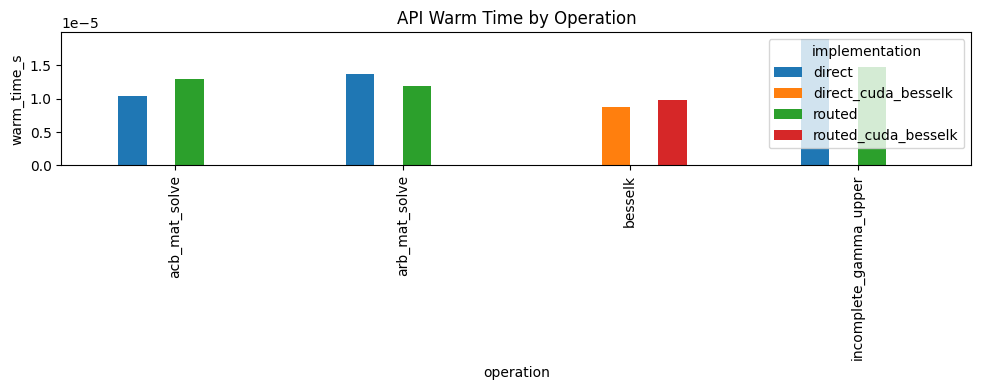

In [13]:
pivot = api_df.pivot(index='operation', columns='implementation', values='warm_time_s')
ax = pivot.plot(kind='bar', figsize=(10, 4), title='API Warm Time by Operation')
ax.set_ylabel('warm_time_s')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'api_warm_time_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Optional Diagnostics

For compile/memory diagnostics beyond the API benchmark, use `benchmark_matrix_stack_diagnostics.py` or the JAX diagnostics helpers explicitly.

In [14]:
summary_lines = [
    f'# Example API Surface Summary ({JAX_MODE})',
    '',
    f'- python: `{PYTHON}`',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- api_rows: `{len(api_df)}`',
    f'- diagnostics_rows: `{len(diag_df)}`',
    '',
    '## Routed Operations',
    '',
]
for row in summary.reset_index().to_dict(orient='records'):
    summary_lines.append(f"- `{row['operation']}` / `{row['implementation']}`: warm={row['warm_time_s']:.6g}s, cold={row['cold_time_s']:.6g}s, recompile={row['recompile_time_s']:.6g}s")
summary_lines.extend(['', '## Diagnostics Cases', ''])
for row in diag_df.to_dict(orient='records'):
    summary_lines.append(f"- `{row['name']}`: compile_ms={row['compile_ms']:.6g}, steady_ms_median={row['steady_ms_median']:.6g}, recompile_new_shape_ms={row['recompile_new_shape_ms']:.6g}")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:16]))

'# Example API Surface Summary (cpu)\n\n- python: `/home/phili/miniforge3/envs/jax/bin/python`\n- backend: `cpu`\n- api_rows: `8`\n- diagnostics_rows: `8`\n\n## Routed Operations\n\n- `acb_mat_solve` / `direct`: warm=1.03997e-05s, cold=0.206161s, recompile=1.0394e-05s\n- `acb_mat_solve` / `routed`: warm=1.2917e-05s, cold=0.144443s, recompile=1.1234e-05s\n- `arb_mat_solve` / `direct`: warm=1.37173e-05s, cold=0.412853s, recompile=1.2744e-05s\n- `arb_mat_solve` / `routed`: warm=1.19683e-05s, cold=0.118087s, recompile=9.526e-06s\n- `besselk` / `direct_cuda_besselk`: warm=8.76833e-06s, cold=0.149198s, recompile=8.554e-06s\n- `besselk` / `routed_cuda_besselk`: warm=9.777e-06s, cold=0.358417s, recompile=1.0508e-05s\n- `incomplete_gamma_upper` / `direct`: warm=1.9013e-05s, cold=0.150323s, recompile=2.0815e-05s'